In [1]:
import numpy as np
from scipy.integrate import quad_vec
import matplotlib.pyplot as plt
import time
from contextlib import contextmanager
from dataclasses import dataclass

In [ ]:
MU_0 = 4e-7 * np.pi
EPS_0 = 8.8541878188e-12
ETA_0 = np.sqrt(MU_0/EPS_0)
C = 1/np.sqrt(MU_0*EPS_0)

Далее буду использовать конвенцию кастомных (не общепринятая нотация) T-матриц: 
$$
\begin{pmatrix}
    V_1\\
    U_1
\end{pmatrix}
=
\begin{pmatrix}
    T_{11} & T_{12}\\
    T_{21} & T_{22}
\end{pmatrix}
\begin{pmatrix}
    V_2\\
    U_2
\end{pmatrix}
$$
здесь $V$ &mdash; это напряжения, а $U=\frac{I Z_0}{i}$, удобно токи поделить на мнимую единицу так как фаза токов в стоячей волне отличается от фазы напряжений как раз на $\pi/4$

In [92]:
@contextmanager
def timer():
    start = time.perf_counter()
    yield
    print(f"Время выполнения: {time.perf_counter() - start:.4f}s")

In [93]:
class FreeSpaceLayer: # beta=k_z*l на основной частоте при нормальном падении, df - относительная расстройка
    def __init__(self, beta, theta, df):
        self.theta = theta[None, :, None]
        self.df = df[None, None, :]
        self.beta_real = beta*(1+self.df)*np.cos(self.theta)
    def Tmatrix(self):
        t_mat = np.array([[np.cos(self.beta_real), np.sin(self.beta_real)],
                        [-np.sin(self.beta_real), np.cos(self.beta_real)]], dtype=float)
        return t_mat.transpose(2,3,4,0,1) # [phi][theta][df][*][*] (последние 2 измерения - ОБРАТНАЯ Т-матрица)

In [148]:
class ImpSheetLayer: # alpha - ETA_0/X_s на основной частоте при нормальном падении, df - относительная расстройка, polarization ('TE' или 'TM'), dispersion ('ind' или 'cap')
    def __init__(self, alpha, theta, df, polarization, dispersion = 'ind'):
        self.theta = theta[None, :, None]
        self.df = df[None, None, :]
        self.like_df = np.ones_like(self.df)
        self.like_theta = np.ones_like(self.theta)
        if dispersion == 'ind':
            self.alpha_real = alpha/(1+self.df)
        elif dispersion == 'cap':
            self.alpha_real = alpha*(1+self.df)
        if polarization == 'TE':
            self.alpha_real = self.alpha_real/np.cos(self.theta)
        elif polarization == 'TM':
            self.alpha_real = self.alpha_real*np.cos(self.theta)
    def Tmatrix(self):
        t_mat = np.array([[1*self.like_df*self.like_theta, 0*self.like_df*self.like_theta],
                        [self.alpha_real, 1*self.like_df*self.like_theta]], dtype=float)
        return t_mat.transpose(2,3,4,0,1) # [phi][theta][df][*][*] (последние 2 измерения - ОБРАТНАЯ Т-матрица)

In [1]:
class LayeredStructure:

    def __init__(self, alpha, beta = 'first_approx'):
        self.N = len(alpha)
        self.alpha = alpha
        if beta == 'first_approx':
            self.beta = self.first_approx_max_gain()
        else:
            self.beta = beta
        self.dispersion = ['ind']*self.N
        for i in range(self.N):
            if self.alpha[i] < 0:
                self.dispersion[i] = 'cap'

    def directivity(self, df): # df - относительная расстройка (np.array) 
        def denom_func(theta):
            theta = np.array([theta])
            T_shift = FreeSpaceLayer(np.pi/2, theta, df).Tmatrix()
            vec_0 = np.array([0,1])[None, None, None, :,None]
            p_s = ((T_shift@vec_0).transpose(0,1,4,3,2)[0, 0, 0, 0, :])**2
            vec_TM = np.array([0,1])[None, None, None, :,None]
            vec_TE = np.array([0,1])[None, None, None, :,None]
            for i in range(self.N):
                vec_TM = FreeSpaceLayer(self.beta[i], theta, df).Tmatrix()@vec_TM
                vec_TM = ImpSheetLayer(self.alpha[i], theta, df, 'TM', self.dispersion[i]).Tmatrix()@vec_TM
                vec_TE = FreeSpaceLayer(self.beta[i], theta, df).Tmatrix()@vec_TE
                vec_TE = ImpSheetLayer(self.alpha[i], theta, df, 'TE', self.dispersion[i]).Tmatrix()@vec_TE
            vec_TM = vec_TM.transpose(0,1,4,3,2)[0, 0, 0, :, :]
            vec_TE = vec_TE.transpose(0,1,4,3,2)[0, 0, 0, :, :]
            p_TM = (vec_TM[0, :]**2 + vec_TM[1, :]**2)
            p_TE = (vec_TE[0, :]**2 + vec_TE[1, :]**2)
            p_xi_TM = p_s/p_TM
            p_xi_TE = p_s/p_TE
            return  np.cos(theta)**2 *p_xi_TM + p_xi_TE
        p_norm = denom_func(0)/2
        integral, eps = quad_vec(lambda theta: denom_func(theta)*np.sin(theta), 0, np.pi/2*0.99, epsrel=1e-5)
        return 4*p_norm/integral # выводит массив directivity для каждой df
    
    def radiation_pattern(self, phi, theta, df, mode='normalized'):
        def p_on_direction_array(phi, theta, df):
            T_shift = FreeSpaceLayer(np.pi/2, theta, df).Tmatrix() # [phi][theta][df][*][*]
            vec_0 = np.array([0,1])[None, None, None, :,None]
            p_s = ((T_shift@vec_0).transpose(4,3,2,0,1)[0, 0, :, :, :])**2 # [df][phi][theta]
            vec_TM = np.array([0,1])[None, None, None, :,None]
            vec_TE = np.array([0,1])[None, None, None, :,None]
            for i in range(self.N):
                vec_TM = FreeSpaceLayer(self.beta[i], theta, df).Tmatrix()@vec_TM
                vec_TM = ImpSheetLayer(self.alpha[i], theta, df, 'TM', self.dispersion[i]).Tmatrix()@vec_TM
                vec_TE = FreeSpaceLayer(self.beta[i], theta, df).Tmatrix()@vec_TE
                vec_TE = ImpSheetLayer(self.alpha[i], theta, df, 'TE', self.dispersion[i]).Tmatrix()@vec_TE
            vec_TM = vec_TM.transpose(4, 3, 2, 0, 1)[0, :, :, :, :] 
            vec_TE = vec_TE.transpose(4, 3, 2, 0, 1)[0, :, :, :, :]
            # удалена фиктивная матричная ось, теперь [компоненты вектора][df][phi][theta]
            p_TM = (vec_TM[0, :, :, :]**2 + vec_TM[1, :, :, :]**2) # [df][phi][theta]
            p_TE = (vec_TE[0, :, :, :]**2 + vec_TE[1, :, :, :]**2)
            p_xi_TM = p_s/p_TM
            p_xi_TE = p_s/p_TE
            phi = phi[None, :, None]
            p = np.cos(theta)**2*np.cos(phi)**2*p_xi_TM + np.sin(phi)**2*p_xi_TE
            return p
        p_total = p_on_direction_array(phi, theta, df)/p_on_direction_array(np.array([0]), np.array([0]), df)
        if mode == 'normalized':
            return p_total
        elif mode == 'absolute':
            return p_total*(self.directivity(df)[:, None, None])
        
    def first_approx_max_gain(self):
        alpha = self.alpha
        beta = np.arctan((alpha-np.sign(alpha)*np.sqrt(alpha**2+4))/2)+np.pi
        psi = np.arctan(np.tan(beta)/(alpha*np.tan(beta)+1))
        beta1 = np.zeros_like(beta)
        for i in range(1, len(beta)):
            beta1[i] = beta[i] - psi[i-1]
            if beta1[i] > np.pi:
                beta1[i] -= np.pi
        beta1[0] = beta[0]
        return beta1
    
    def max_gain_and_bandwidth(self, df):
        directivity = self.directivity(df)
        max_dir_i = np.argmax(directivity)
        max_dir = directivity[max_dir_i]
        i = max_dir_i
        while i > 0 and (max_dir - directivity[i]) < 3:
            i -= 1
        left_df = df[i]
        i = max_dir_i
        while i < len(df)-1 and (max_dir - directivity[i]) < 3:
            i += 1
        right_df = df[i]
        return max_dir, (right_df - left_df)*100

In [264]:
@dataclass
class Style:
    ax_label_size: int = 14
    tick_label_size: int = 12
    legend_size: int = 10
    grid_alpha: float = 0.3
    grid_linestyle: str = '--'
    grid_linewidth: int = 1 
    line_width: int = 2.5
    cmap: str = 'viridis'

class Plotter:
    def __init__(self, ax, style: Style):
        self.ax = ax
        self.style = style
    def set_xlabel(self, xlabel):
        self.ax.set_xlabel(xlabel, fontsize=self.style.ax_label_size)
        return self
    def set_ylabel(self, ylabel):
        self.ax.set_ylabel(ylabel, fontsize=self.style.ax_label_size)
        return self
    def set_ylim(self, ylim):
        self.ax.set_ylim(ylim)
        return self
    def set_title(self, title):
        self.ax.set_title(title, fontsize=self.style.ax_label_size)
        return self
    def set_legend(self, legend_loc = 'best'):
        self.legend_loc = legend_loc
        return self
    def set_p(self, p):
        self.p = p
        self.cmap = plt.get_cmap(self.style.cmap)
        self.norm = plt.Normalize(min(self.p), max(self.p))
        return self
    
    def plot(self, x, y, label=''):
        self.ax.plot(x, y, label=label, linewidth=self.style.line_width)

    def multiple_plot(self, xi, yi, p_i, label=''):
        self.ax.plot(xi, yi, label=label, color=self.cmap(self.norm(p_i)), linewidth=self.style.line_width)

    def finalize(self):
        self.ax.tick_params(axis='both', which='major', labelsize=self.style.tick_label_size)
        self.ax.grid(alpha=self.style.grid_alpha, linestyle=self.style.grid_linestyle, linewidth=self.style.grid_linewidth)
        
        handles, labels = self.ax.get_legend_handles_labels()
        if labels:
            if not hasattr(self, 'legend_loc'):
                self.legend_loc = 'best'
            self.ax.legend(fontsize=self.style.legend_size, loc=self.legend_loc)
        


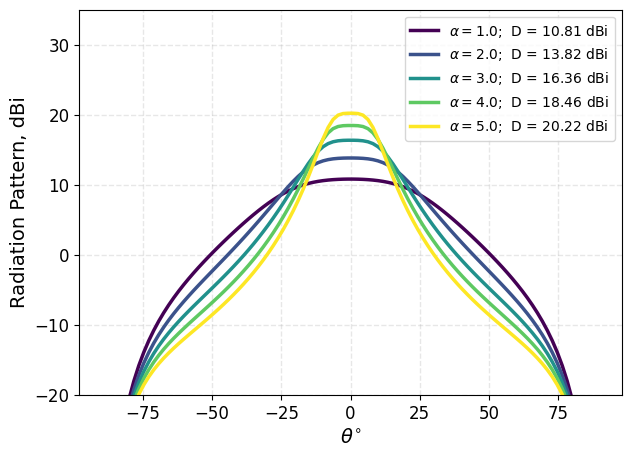

In [ ]:
st = Style()
alpha = np.array([1, 2, 3, 4, 5], dtype=float)[:, None]
fig, ax = plt.subplots(figsize=(7, 5))
theta = np.linspace(-np.pi/2*0.99, np.pi/2*0.99, 100)
pl = Plotter(ax, st)
pl.set_xlabel(r'$\theta^{\circ}$')
pl.set_ylabel('Radiation Pattern, dBi')
pl.set_ylim((-20, 35))
pl.set_p(alpha)
for a in alpha:
    b = np.atan((a-np.sqrt(a**2+4))/2)+np.pi
    structure = LayeredStructure(a, b)
    df = np.array([0])
    phi = np.array([0])
    angle = theta*180/np.pi
    pdB = 10*np.log10(structure.radiation_pattern(phi, theta, df, mode='absolute')[0, 0, :])
    dir = 10*np.log10(structure.directivity(df))
    label = (r'$\alpha={}$'.format(a[0]) + '; ' + ' D = ' + f"{dir[0]:.2f} dBi")
    pl.multiple_plot(angle, pdB, a[0], label=label)
pl.finalize()
plt.show()

In [273]:
alpha = np.array([1.5, -1.5, 1.5])
beta = np.arctan((alpha-np.sign(alpha)*np.sqrt(alpha**2+4))/2)+np.pi
psi = np.arctan(np.tan(beta)/(alpha*np.tan(beta)+1))
beta1 = np.zeros_like(beta)
for i in range(1, len(beta)):
    beta1[i] = beta[i] - psi[i-1]
    if beta1[i] > np.pi:
        beta1[i] -= np.pi
beta1[0] = beta[0]
k = 2*np.pi*5e9/C
print(beta1/k)

[0.0255548  0.01498962 0.01498962]


Directivity: 24.06 dBi


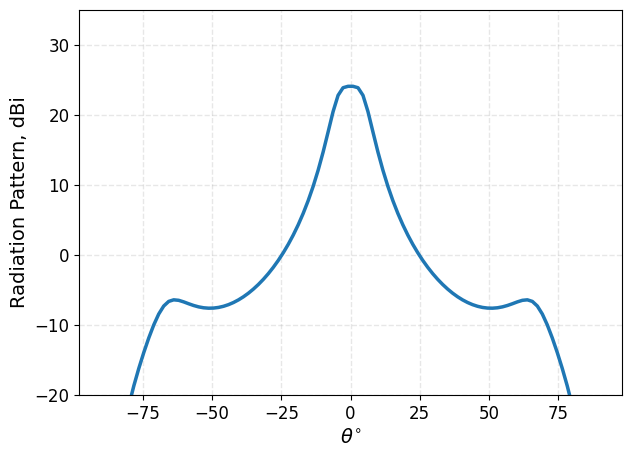

In [274]:
theta = np.linspace(-np.pi/2*0.99, np.pi/2*0.99, 100)
df = np.array([0])
phi = np.array([0])
structure = LayeredStructure(alpha, beta1)
angle = theta*180/np.pi
pdB = 10*np.log10(structure.radiation_pattern(phi, theta, df, mode='absolute')[0, 0, :])
dir = 10*np.log10(structure.directivity(df))
print(f"Directivity: {dir[0]:.2f} dBi")
fig, ax = plt.subplots(figsize=(7, 5))
pl = Plotter(ax, st)
pl.set_xlabel(r'$\theta^{\circ}$')
pl.set_ylabel('Radiation Pattern, dBi')
pl.set_ylim((-20, 35))
pl.plot(angle, pdB)
pl.finalize()
plt.show()

Полоса по уровню 3 дБ: 1.36 %
Полоса 3 дБ: [-0.0108, 0.0028] (относительная расстройка)
Макс. директивность: 24.61 dBi при df = -0.0018 (относительная расстройка)


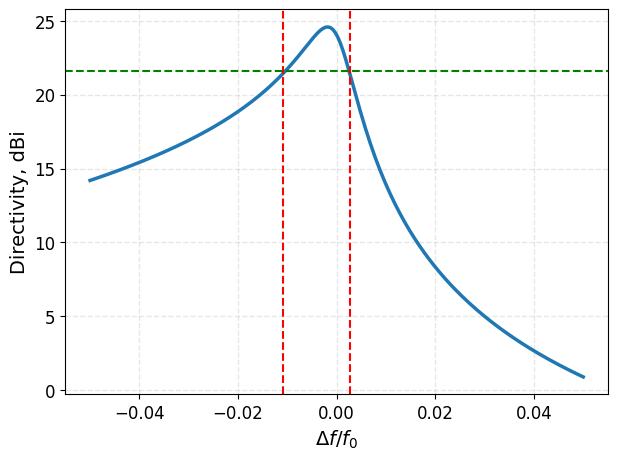

In [287]:
df = np.linspace(-0.05, 0.05, 200)
Dir_vs_df = 10*np.log10(structure.directivity(df))
max_dir_i = np.argmax(Dir_vs_df)
max_dir = Dir_vs_df[max_dir_i]
i = max_dir_i
while i > 0 and (Dir_vs_df[max_dir_i] - Dir_vs_df[i]) < 3:
    i -= 1
left_df = df[i]
i = max_dir_i
while i < len(df)-1 and (Dir_vs_df[max_dir_i] - Dir_vs_df[i]) < 3:
    i += 1
right_df = df[i]
print(f"Полоса по уровню 3 дБ: {(right_df-left_df)*100:.2f} %")
print(f"Полоса 3 дБ: [{left_df:.4f}, {right_df:.4f}] (относительная расстройка)")
print(f"Макс. директивность: {max_dir:.2f} dBi при df = {df[max_dir_i]:.4f} (относительная расстройка)")
fig, ax = plt.subplots(figsize=(7, 5))
pl = Plotter(ax, st)
pl.set_xlabel(r'$\Delta f/f_0$')
pl.set_ylabel('Directivity, dBi')
pl.plot(df, Dir_vs_df)
ax.axvline(left_df, color='red', linestyle='--')
ax.axvline(right_df, color='red', linestyle='--')
ax.axhline(max_dir-3, color='green', linestyle='--')
pl.finalize()
plt.show()

In [133]:
#cmap = plt.cm.viridis
df = np.linspace(-0.2, 0.1, 200)

a = 2*np.array([1.2, 1.5, 1.8, 2.1, 2.4])
b = np.atan((a-np.sqrt(a**2+4))/2)+np.pi
dispersion = ['ind']
#norm = plt.Normalize(min(a), max(a))
with timer():
    for i in range(len(a)):
        alph = np.array([a[i]])
        beta = np.array([b[i]])
        structure = LayeredStructure(alph, beta, dispersion)
        k = 10*np.log10(structure.directivity(df))
    #plt.plot(df, 10*np.log10(structure.directivity(df)), label=(r'$\alpha=$' + f"{alph[0]:.2g}"), color=cmap(norm(alph[0])), linewidth=2.5)
    #print(10*np.log10(structure.directivity(df)))
# plt.legend(fontsize=12)
# plt.xticks(fontsize=12)
# plt.yticks(fontsize=12)
# plt.xlabel(r'$\Delta f / f_0$, %', fontsize=14)
# plt.ylabel('Directivity, dBi', fontsize=14)
# plt.grid(alpha=0.3)
# plt.ylim(10, 25)
# plt.show()

Время выполнения: 0.1696s


In [98]:
print(4*60/0.15)

1600.0
